# Practical 01: Simple Linear Regression

## Dataset: Iris Dataset (Setosa class)
## Subject: Machine Learning

This practical demonstrates Simple Linear Regression using multiple approaches:

1. Covariance (Statistical) Method
2. Normal Equation (Matrix Method)
3. Gradient Descent (Homework)
4. sklearn Inbuilt Method (Homework)


## Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression

## Load Dataset

In [2]:
iris = load_iris()

X = iris.data[:50, 0]
Y = iris.data[:50, 1]

## Method 1: Covariance (Statistical) Method

In [3]:
x_mean = np.mean(X)
y_mean = np.mean(Y)

cov_xy = np.mean((X - x_mean) * (Y - y_mean))
var_x = np.mean((X - x_mean) ** 2)

m1 = cov_xy / var_x
c1 = y_mean - m1 * x_mean

print("Slope:", m1)
print("Intercept:", c1)

Slope: 0.7985283006471532
Intercept: -0.5694326730396493


## Method 2: Normal Equation (Matrix Method)

In [4]:
X_matrix = X.reshape(-1, 1)
Y_matrix = Y.reshape(-1, 1)

X_design = np.hstack((np.ones((X_matrix.shape[0], 1)), X_matrix))

theta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ Y_matrix

print("Slope:", theta[1][0])
print("Intercept:", theta[0][0])

Slope: 0.7985283006471879
Intercept: -0.5694326730399227


## Method 3: Gradient Descent

In [5]:
learning_rate = 0.01
epochs = 1000
m = 0
c = 0
n = len(X)

for i in range(epochs):
    y_pred = m * X + c
    dm = (-2/n) * np.sum(X * (Y - y_pred))
    dc = (-2/n) * np.sum(Y - y_pred)
    m -= learning_rate * dm
    c -= learning_rate * dc

print("Slope:", m)
print("Intercept:", c)

Slope: 0.6716186415698543
Intercept: 0.06884605805400948


## Method 4: sklearn LinearRegression

In [6]:
model = LinearRegression()
model.fit(X.reshape(-1,1), Y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 0.798528300647153
Intercept: -0.569432673039648


## Visualization

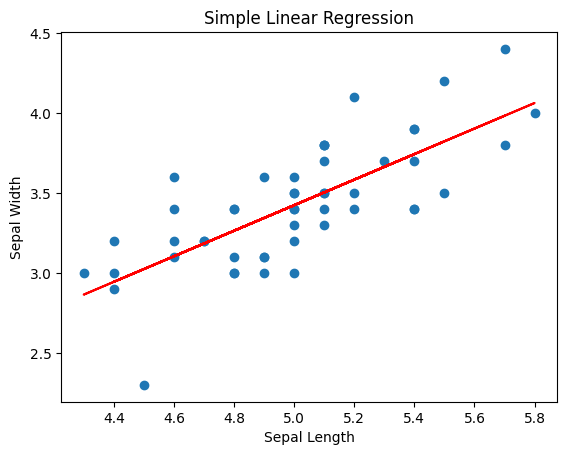

In [7]:
plt.scatter(X, Y)
plt.plot(X, model.predict(X.reshape(-1,1)), color='red')
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Simple Linear Regression")
plt.show()

## Conclusion

All four approaches produced similar regression parameters. Gradient descent demonstrated iterative optimization while sklearn provided an efficient built-in implementation.